# K-Nearest Neighbors (Horse Survival Prediction)

## Penjelasan

### Tujuan

Membuat model machine learning yang dapat memprediksi kondisi kesehatan kuda, menggunakan algoritma K-Nearest Neighbors (KNN)

### Penjelasan Kolom

- ***surgery***: 1 = Yes, it had surgery 2 = It was treated without surgery
- ***age***: 1 = Adult horse 2 = Young (< 6 months)

## A. Data Preparation

### A.1 Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

### A.2 Load Data

In [37]:
try:
    df_train = pd.read_csv('train.csv')
    df_test = pd.read_csv('test.csv')
    print('Berhasil Membaca Data')
except Exception as e:
    print('Gagal Membaca Data')

Berhasil Membaca Data


### A.3 Melihat Dimensi Data

In [38]:
print(f'Dimensi Data Train: {df_train.shape}')
print(f'Dimensi Data Test: {df_test.shape}')

Dimensi Data Train: (1235, 29)
Dimensi Data Test: (824, 28)


### A.4 Melihat Informasi Data

In [39]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1235 non-null   int64  
 1   surgery                1235 non-null   object 
 2   age                    1235 non-null   object 
 3   hospital_number        1235 non-null   int64  
 4   rectal_temp            1235 non-null   float64
 5   pulse                  1235 non-null   float64
 6   respiratory_rate       1235 non-null   float64
 7   temp_of_extremities    1196 non-null   object 
 8   peripheral_pulse       1175 non-null   object 
 9   mucous_membrane        1214 non-null   object 
 10  capillary_refill_time  1229 non-null   object 
 11  pain                   1191 non-null   object 
 12  peristalsis            1215 non-null   object 
 13  abdominal_distention   1212 non-null   object 
 14  nasogastric_tube       1155 non-null   object 
 15  naso

In [40]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     824 non-null    int64  
 1   surgery                824 non-null    object 
 2   age                    824 non-null    object 
 3   hospital_number        824 non-null    int64  
 4   rectal_temp            824 non-null    float64
 5   pulse                  824 non-null    float64
 6   respiratory_rate       824 non-null    float64
 7   temp_of_extremities    789 non-null    object 
 8   peripheral_pulse       777 non-null    object 
 9   mucous_membrane        811 non-null    object 
 10  capillary_refill_time  818 non-null    object 
 11  pain                   795 non-null    object 
 12  peristalsis            805 non-null    object 
 13  abdominal_distention   802 non-null    object 
 14  nasogastric_tube       760 non-null    object 
 15  nasoga

### A.5 Melihat Statistik Data

In [41]:
df_train.describe().T.style.format('{:.2f}').background_gradient(cmap='flare')

,count,mean,std,min,25%,50%,75%,max
id,1235.00,617.00,356.66,0.00,308.50,617.00,925.50,1234.00
hospital_number,1235.00,954500.40,1356403.14,521399.00,528800.00,529777.00,534145.00,5305129.00
rectal_temp,1235.00,38.20,0.79,35.40,37.80,38.20,38.60,40.80
pulse,1235.00,79.57,29.11,30.00,53.00,76.00,100.00,184.00
respiratory_rate,1235.00,30.05,16.45,8.00,18.00,28.00,36.00,96.00
nasogastric_reflux_ph,1235.00,4.38,1.94,1.00,2.00,4.50,6.00,7.50
packed_cell_volume,1235.00,49.60,10.54,23.00,43.00,48.00,57.00,75.00
total_protein,1235.00,21.39,26.68,3.50,6.60,7.50,9.10,89.00
abdomo_protein,1235.00,3.29,1.59,0.10,2.00,3.00,4.30,10.10
lesion_1,1235.00,3832.50,5436.73,0.00,2205.00,2209.00,3205.00,41110.00


### A.6 Melihat 5 Data Teratas dan 5 Data Terbawah

In [42]:
df_train.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,0,yes,adult,530001,38.1,132.0,24.0,cool,reduced,dark_cyanotic,more_3_sec,depressed,absent,slight,slight,less_1_liter,6.5,decreased,distend_small,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,1,yes,adult,533836,37.5,88.0,12.0,cool,normal,pale_cyanotic,more_3_sec,mild_pain,absent,moderate,none,more_1_liter,2.0,absent,distend_small,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,2,yes,adult,529812,38.3,120.0,28.0,cool,reduced,pale_pink,less_3_sec,extreme_pain,hypomotile,moderate,slight,none,3.5,NaN,distend_large,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,3,yes,adult,5262541,37.1,72.0,30.0,cold,reduced,pale_pink,more_3_sec,mild_pain,hypomotile,moderate,slight,more_1_liter,2.0,decreased,distend_small,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,4,no,adult,5299629,38.0,52.0,48.0,normal,normal,normal_pink,less_3_sec,alert,hypomotile,none,slight,less_1_liter,7.0,normal,normal,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


In [43]:
df_train.tail()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
1230,1230,yes,adult,535246,38.5,129.0,48.0,cool,reduced,pale_pink,more_3_sec,depressed,absent,moderate,none,more_1_liter,2.0,NaN,distend_large,57.0,66.0,serosanguious,2.0,yes,2206,0,0,no,lived
1231,1231,yes,adult,528570,37.5,60.0,50.0,cool,reduced,pale_cyanotic,less_3_sec,mild_pain,hypomotile,slight,slight,none,3.0,decreased,distend_small,35.0,6.4,serosanguious,3.6,yes,2209,0,0,yes,died
1232,1232,yes,young,529685,37.5,84.0,40.0,normal,reduced,normal_pink,less_3_sec,mild_pain,hypomotile,slight,slight,none,3.0,increased,firm,40.0,5.9,cloudy,7.0,yes,400,0,0,yes,lived
1233,1233,yes,adult,534784,38.1,70.0,16.0,normal,reduced,bright_red,less_3_sec,mild_pain,hypomotile,slight,none,more_1_liter,2.0,absent,distend_small,58.0,74.0,cloudy,2.0,yes,2209,0,0,no,lived
1234,1234,yes,adult,528548,38.1,54.0,36.0,normal,normal,pale_pink,less_3_sec,mild_pain,absent,none,slight,none,3.0,NaN,distend_small,45.0,6.0,clear,3.6,yes,2124,0,0,yes,lived


In [44]:
df_test.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,1235,no,adult,534053,38.6,40.0,20.0,normal,normal,normal_pink,less_3_sec,mild_pain,hypomotile,slight,none,none,7.0,normal,distend_small,42.0,7.5,clear,2.3,no,0,0,0,no
1,1236,yes,adult,528469,38.2,112.0,48.0,cool,reduced,bright_pink,more_3_sec,depressed,hypomotile,moderate,slight,none,3.5,decreased,distend_small,44.0,6.0,serosanguious,2.6,no,2208,0,0,yes
2,1237,yes,adult,528178,37.7,66.0,12.0,cool,normal,bright_red,less_3_sec,mild_pain,hypomotile,slight,slight,none,3.0,normal,distend_small,31.5,6.0,cloudy,1.6,yes,2205,0,0,yes
3,1238,no,adult,534784,37.1,88.0,20.0,cool,reduced,pale_cyanotic,less_3_sec,depressed,absent,severe,slight,more_1_liter,2.0,absent,distend_large,75.0,81.0,NaN,1.0,yes,1400,0,0,no
4,1239,yes,adult,529840,38.3,50.0,12.0,NaN,normal,bright_pink,less_3_sec,mild_pain,absent,slight,slight,none,3.0,decreased,distend_small,37.0,6.8,cloudy,2.6,yes,2208,0,0,yes


In [45]:
df_test.tail()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
819,2054,no,adult,529461,40.3,114.0,36.0,cool,reduced,normal_pink,more_3_sec,depressed,hypomotile,moderate,NaN,none,7.0,normal,distend_large,57.0,8.1,serosanguious,4.5,yes,3205,0,0,yes
820,2055,yes,adult,535338,37.2,100.0,20.0,cool,reduced,pale_cyanotic,more_3_sec,extreme_pain,absent,moderate,slight,more_1_liter,2.0,absent,distend_small,50.0,66.0,serosanguious,2.0,yes,2209,0,0,no
821,2056,yes,adult,529640,39.2,132.0,12.0,cool,reduced,dark_cyanotic,more_3_sec,depressed,hypomotile,moderate,slight,more_1_liter,6.5,decreased,NaN,53.0,7.6,serosanguious,4.5,yes,2205,0,0,no
822,2057,no,adult,5287179,38.3,54.0,66.0,normal,normal,normal_pink,less_3_sec,mild_pain,hypomotile,none,slight,none,7.0,normal,NaN,49.0,8.6,clear,5.0,no,3111,0,0,yes
823,2058,yes,adult,528461,38.1,66.0,12.0,cold,normal,normal_pink,less_3_sec,mild_pain,hypomotile,slight,slight,more_1_liter,2.0,absent,distend_small,31.5,6.2,NaN,1.6,yes,2205,0,0,yes


### A.7 Melihat Data Duplikat

In [46]:
print(df_train.duplicated().sum())
print(df_test.duplicated().sum())

0
0


### A.8 Melihat Data Hilang

In [47]:
print(df_train.isna().sum())
print(df_test.isna().sum())

id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
pulse                      0
respiratory_rate           0
temp_of_extremities       39
peripheral_pulse          60
mucous_membrane           21
capillary_refill_time      6
pain                      44
peristalsis               20
abdominal_distention      23
nasogastric_tube          80
nasogastric_reflux        21
nasogastric_reflux_ph      0
rectal_exam_feces        190
abdomen                  213
packed_cell_volume         0
total_protein              0
abdomo_appearance         48
abdomo_protein             0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
outcome                    0
dtype: int64
id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
p

Karena terdapat data hilang dari kedua dataframe, kami memutuskan untuk mengisi data hilang menggunakan Mean & Mode

In [48]:
## Kolom Numeric Diisi Rata-Rata (Mean)
for cols in df_train.select_dtypes(include=['number']).columns:
    df_train[cols] = df_train[cols].fillna(df_train[cols].mean())
    
## Kolom Object Diisi Kata Yang Sering Muncul (Modus/Mode)
for cols in df_train.select_dtypes(include=['object']).columns:
    df_train[cols] = df_train[cols].fillna(df_train[cols].mode()[0])

In [49]:
## Kolom Numeric Diisi Rata-Rata (Mean)
for cols in df_test.select_dtypes(include=['number']).columns:
    df_test[cols] = df_test[cols].fillna(df_test[cols].mean())

## Kolom Object Diisi Kata Yang Sering Muncul (Modus/Mode)
for cols in df_test.select_dtypes(include=['object']).columns:
    df_test[cols] = df_test[cols].fillna(df_test[cols].mode()[0])

In [50]:
print(df_train.isna().sum())
print(df_test.isna().sum())

id                       0
surgery                  0
age                      0
hospital_number          0
rectal_temp              0
pulse                    0
respiratory_rate         0
temp_of_extremities      0
peripheral_pulse         0
mucous_membrane          0
capillary_refill_time    0
pain                     0
peristalsis              0
abdominal_distention     0
nasogastric_tube         0
nasogastric_reflux       0
nasogastric_reflux_ph    0
rectal_exam_feces        0
abdomen                  0
packed_cell_volume       0
total_protein            0
abdomo_appearance        0
abdomo_protein           0
surgical_lesion          0
lesion_1                 0
lesion_2                 0
lesion_3                 0
cp_data                  0
outcome                  0
dtype: int64
id                       0
surgery                  0
age                      0
hospital_number          0
rectal_temp              0
pulse                    0
respiratory_rate         0
temp_of_extremi

## B. Data Preprocessing

### B.1 Drop Unrelated Columns

In [51]:
df_train.columns

Index(['id', 'surgery', 'age', 'hospital_number', 'rectal_temp', 'pulse',
       'respiratory_rate', 'temp_of_extremities', 'peripheral_pulse',
       'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis',
       'abdominal_distention', 'nasogastric_tube', 'nasogastric_reflux',
       'nasogastric_reflux_ph', 'rectal_exam_feces', 'abdomen',
       'packed_cell_volume', 'total_protein', 'abdomo_appearance',
       'abdomo_protein', 'surgical_lesion', 'lesion_1', 'lesion_2', 'lesion_3',
       'cp_data', 'outcome'],
      dtype='object')

In [52]:
df_train.drop(columns=['id', 'hospital_number'], inplace=True)
df_test.drop(columns=['id', 'hospital_number'], inplace=True)

### B.2 Handling Outliers

In [53]:
num = df_train.select_dtypes(include='number')
for col in num:
    Q1 =  df_train[col].quantile(0.25)
    Q3 =  df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    if IQR > 0:
        low_b = Q1 - IQR * 1.5
        upp_b = Q3 + IQR * 1.5
        
        df_train_clean = df_train[(df_train[col] > low_b) & (df_train[col] < upp_b)]

In [54]:
print(f'Data Train Sebelum Handling Outliers: {df_train.shape}')
print(f'Data Train Setelah Handling Outliers: {df_train_clean.shape}')

Data Train Sebelum Handling Outliers: (1235, 27)
Data Train Setelah Handling Outliers: (929, 27)


In [55]:
num = df_test.select_dtypes(include='number')
for col in num:
    Q1 =  df_test[col].quantile(0.25)
    Q3 =  df_test[col].quantile(0.75)
    IQR = Q3 - Q1
    
    if IQR > 0:
        low_b = Q1 - IQR * 1.5
        upp_b = Q3 + IQR * 1.5
        
        df_test_clean = df_test[(df_test[col] > low_b) & (df_test[col] < upp_b)]

In [56]:
print(f'Data Test Sebelum Handling Outliers: {df_test.shape}')
print(f'Data Test Setelah Handling Outliers: {df_test_clean.shape}')

Data Test Sebelum Handling Outliers: (824, 26)
Data Test Setelah Handling Outliers: (608, 26)


### B.3 Mapping Features & Target (Object Columns)

In [57]:
df_train_map = df_train.copy()
df_train_clean_map = df_train.copy()

In [58]:
for cols in df_train.select_dtypes(include='object'):
    df_train_map[cols] = df_train[cols].astype('category').cat.codes
    df_train_clean_map[cols] = df_train[cols].astype('category').cat.codes

df_train_map.head()

,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,1,0,38.1,132.0,24.0,1,3,2,2,1,0,3,2,0,6.5,1,1,57.0,8.5,2,3.4,1,2209,0,0,0,0
1,1,0,37.5,88.0,12.0,1,2,4,2,3,0,0,0,1,2.0,0,1,33.0,64.0,2,2.0,1,2208,0,0,0,1
2,1,0,38.3,120.0,28.0,1,3,5,1,2,3,0,2,2,3.5,0,0,37.0,6.4,2,3.4,1,5124,0,0,0,2
3,1,0,37.1,72.0,30.0,0,3,5,2,3,3,0,2,1,2.0,1,1,53.0,7.0,1,3.9,1,2208,0,0,1,2
4,0,0,38.0,52.0,48.0,2,2,3,1,0,3,1,2,0,7.0,3,3,47.0,7.3,1,2.6,0,0,0,0,1,2


In [59]:
df_train.head()

,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,yes,adult,38.1,132.0,24.0,cool,reduced,dark_cyanotic,more_3_sec,depressed,absent,slight,slight,less_1_liter,6.5,decreased,distend_small,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,yes,adult,37.5,88.0,12.0,cool,normal,pale_cyanotic,more_3_sec,mild_pain,absent,moderate,none,more_1_liter,2.0,absent,distend_small,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,yes,adult,38.3,120.0,28.0,cool,reduced,pale_pink,less_3_sec,extreme_pain,hypomotile,moderate,slight,none,3.5,absent,distend_large,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,yes,adult,37.1,72.0,30.0,cold,reduced,pale_pink,more_3_sec,mild_pain,hypomotile,moderate,slight,more_1_liter,2.0,decreased,distend_small,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,no,adult,38.0,52.0,48.0,normal,normal,normal_pink,less_3_sec,alert,hypomotile,none,slight,less_1_liter,7.0,normal,normal,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


## C. Exploratory Data Analysis

## D. Modelling

### D.1 Defining X (Features) and y (Target) Variables

In [60]:
X_data = df_train_map.drop(columns=['outcome'])
y_data = df_train_map['outcome']

### D.2 Splitting Train & Test Data (80 : 20)

In [61]:
def stratified_split(X_data, y_data, train_size=0.8, random_state=42):
    np.random.seed(42)
    
    X_train_list, X_test_list = [], []
    y_train_list, y_test_list = [], []
    
    for class_value in np.unique(y_data):
        class_idx = np.where(y_data == class_value)[0]
        
        idx = np.random.permutation(class_idx)
        split_ratio = int(len(idx) * train_size)
        
        X_train_list.append(X_data.iloc[idx[:split_ratio]])    
        X_test_list.append(X_data.iloc[idx[split_ratio:]])    
        y_train_list.append(y_data.iloc[idx[:split_ratio]])    
        y_test_list.append(y_data.iloc[idx[split_ratio:]])   
        
    X_train = pd.concat(X_train_list).reset_index(drop=True) 
    X_test = pd.concat(X_test_list).reset_index(drop=True) 
    y_train = pd.concat(y_train_list).reset_index(drop=True) 
    y_test = pd.concat(y_test_list).reset_index(drop=True)
    
    return X_train, X_test, y_train, y_test

In [62]:
X_train, X_test, y_train, y_test = stratified_split(X_data, y_data)

In [63]:
print(f"Total Train Data: {X_train.shape}")
print(f"Total Test Data: {X_test.shape}")

Total Train Data: (987, 26)
Total Test Data: (248, 26)


### D.3 Feature Scaling

#### Standard Scale

In [64]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# sns.boxplot(X_train, ax=axes[0])
# axes[0].set_title('Persebaran Boxplot')
# axes[0].tick_params(rotation=90)

# sns.boxenplot(X_train, ax=axes[1])
# axes[1].set_title('Persebaran Boxenplot')
# axes[1].tick_params(rotation=90)

# plt.suptitle('Persebaran Data Fitur Sebelum Scaling', fontsize=18, fontweight="bold")
# plt.tight_layout(rect=[0, 0, 1, 0.9])
# plt.show()

In [65]:
# X_train_mean = X_train.mean()
# X_train_std = X_train.std()

# X_train = (X_train - X_train_mean) / X_train_std
# X_test = (X_test - X_train_mean) / X_train_std

In [66]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# sns.boxplot(X_train, ax=axes[0])
# axes[0].set_title('Persebaran Boxplot')
# axes[0].tick_params(rotation=90)

# sns.boxenplot(X_train, ax=axes[1])
# axes[1].set_title('Persebaran Boxenplot')
# axes[1].tick_params(rotation=90)

# plt.suptitle('Persebaran Data Fitur Setelah Scaling', fontsize=18, fontweight="bold")
# plt.tight_layout(rect=[0, 0, 1, 0.9])
# plt.show()

### D.4 Decision Tree

In [67]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None, prob=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.prob = prob

class DecisionTreeID3:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Stopping Criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            # Hitung Probabilitas (Jumlah Class 1 / Total Data di Node ini)
            prob = np.mean(y == 1) if len(y) > 0 else 0
            return Node(value=leaf_value, prob=prob)

        feat_idxs = np.random.choice(n_features, n_features, replace=False)
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)
        
        if best_feat is None: # Kalau ga bisa split lagi
            leaf_value = self._most_common_label(y)
            prob = np.mean(y == 1)
            return Node(value=leaf_value, prob=prob)

        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feat, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_thresh = None, None
        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for thr in thresholds:
                gain = self._information_gain(y, X_column, thr)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thr
        return split_idx, split_thresh

    def _information_gain(self, y, X_column, threshold):
        parent_entropy = self._entropy(y)
        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0: return 0
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r
        return parent_entropy - child_entropy

    def _split(self, X_column, split_thresh):
        # Karena data PlayTennis kategorikal (0,1,2), kita pakai equality biasannya
        # Tapi biar umum, kita pakai <= (works for logic 0, 1 too)
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        if len(y) == 0: return 0
        return np.bincount(y).argmax()

    def predict_proba(self, X):
        X = np.array(X)
        return np.array([self._traverse_tree_prob(x, self.root) for x in X])

    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= 0.5).astype(int)

    def _traverse_tree_prob(self, x, node):
        if node.value is not None: return node.prob
        if x[node.feature] <= node.threshold:
            return self._traverse_tree_prob(x, node.left)
        return self._traverse_tree_prob(x, node.right)

### D.5 Validation Curve (Finding Optimum Gap)

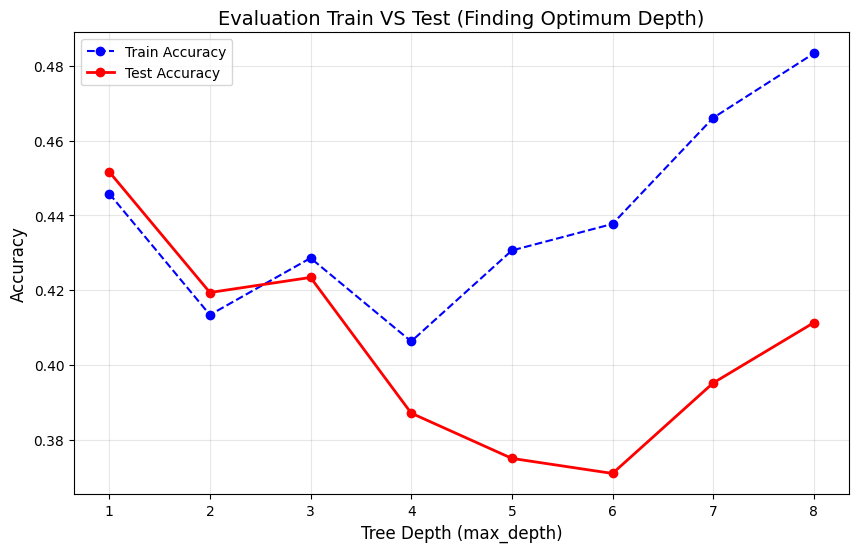

Best Test Accuracy is at Depth: 1


In [ ]:
# --- 1. Validation Curve Logic ---
train_accuracies = []
test_accuracies = []

# tune 'max_depth' for Decision Tree
depth_values = [1, 2, 3, 4, 5, 6, 7, 8]

for d in depth_values:
    # Initialize ID3 Model
    model = DecisionTreeID3(max_depth=d) 
    model.fit(X_train, y_train)
    
    # Train Accuracy
    train_pred = model.predict(X_train)
    train_acc = np.mean(train_pred == y_train)
    train_accuracies.append(train_acc)
    
    # Test Accuracy
    test_pred = model.predict(X_test)
    test_acc = np.mean(test_pred == y_test)
    test_accuracies.append(test_acc)
    

# --- 2. Visualization ---
plt.figure(figsize=(10, 6))

plt.plot(depth_values, train_accuracies, marker='o', linestyle='--', color='blue', label='Train Accuracy')
plt.plot(depth_values, test_accuracies, marker='o', linewidth=2, color='red', label='Test Accuracy')

plt.title('Evaluation Train VS Test (Finding Optimum Depth)', fontsize=14)
plt.xlabel('Tree Depth (max_depth)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(depth_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best Test Accuracy is at Depth: {depth_values[np.argmax(test_accuracies)]}")

#### Grid Search Train Predictions

In [69]:
print("|   K   |   Jarak   |  Accuracy  |    Weights    |")

best_acc = 0
best_params = {}

for k in [3, 5, 7, 9, 11, 13, 15]:
    for p in [1, 2, 'chebyshev']:
        for w in ['uniform', 'distance']:
            model = KNN(k, p, w)
            model.fit(X_train.values, y_train.values)
            pred = model.predict(X_train.values)
            acc = np.mean(pred == y_train.values)
            
            if p == 1:
                dist = 'Manhattan'
            elif p == 2:
                dist = 'Euclidean'
            else:
                dist = 'Chebyshev'
                
            print(f'|   {k}   | {dist} |    {acc:.2f}    |    {w}    |')
            if acc > best_acc:
                best_acc = acc
                best_params = {'k': k, 'p' : p, 'w' : w}
                
if best_params['p'] == 1:
    dist_name = 'Manhattan'
elif best_params['p'] == 2:
    dist_name = 'Euclidean'
else:
    dist_name = 'Chebyshev'
    
print(f"Best K: {best_params['k']} | Best Distance: {dist_name}  | Best Metric: {best_params['w']}  | Best Acc: {best_acc}")

|   K   |   Jarak   |  Accuracy  |    Weights    |


NameError: name 'KNN' is not defined

## E. Evaluation